<div align="center">

<img src="https://img.shields.io/badge/ECS-Veri%20Bilimi%20%26%20YZ%20Uzmanl%C4%B1%C4%9F%C4%B1-5B2C1E?style=for-the-badge&logo=python&logoColor=white" alt="ECS VB&YZ 90"/>

# Hafta 12: Ek: Cnn Balik Siniflandirma

**YAPAY ZEKA MÜHENDİSLİĞİ** · Modül 12 · 6 Saat

---

<a href="https://colab.research.google.com/github/DrMuratAltun/VB-YZ-90/blob/main/notebooks/hafta12/ek_cnn_balik_siniflandirma.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Colab'da Aç"/></a>&nbsp;
<a href="https://github.com/DrMuratAltun/VB-YZ-90/blob/main/notebooks/hafta12/ek_cnn_balik_siniflandirma.ipynb"><img src="https://img.shields.io/badge/GitHub'da%20A%C3%A7-181717?style=flat&logo=github&logoColor=white" alt="GitHub'da Aç"/></a>

</div>

# Proje Hakkında
**Balık Sınıflandırma Projesi**

Veri seti:https://www.kaggle.com/datasets/crowww/a-large-scale-fish-dataset/data

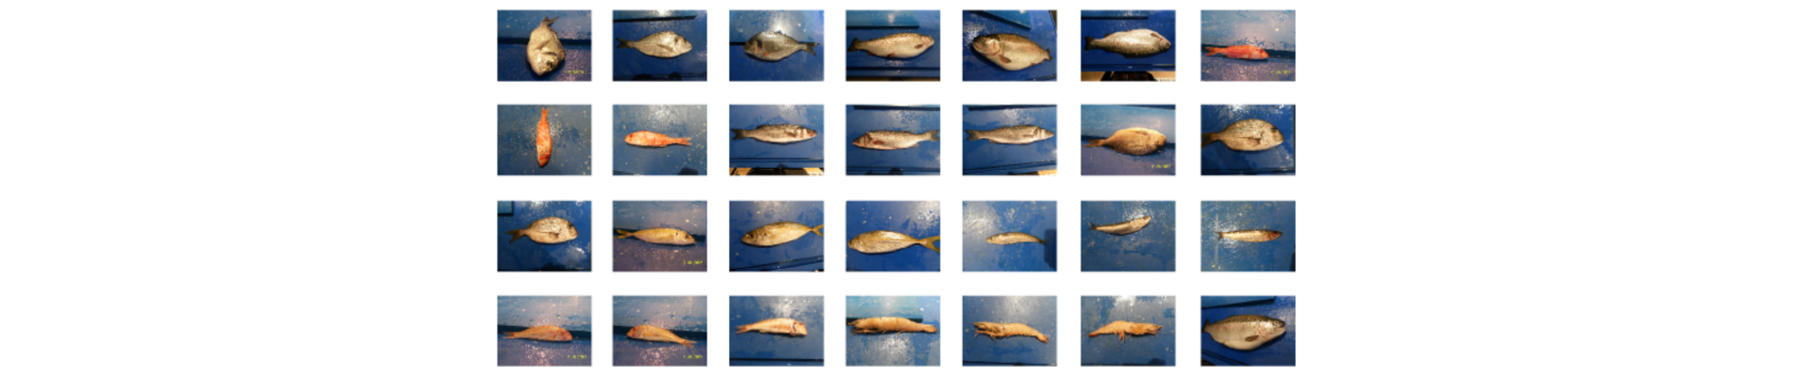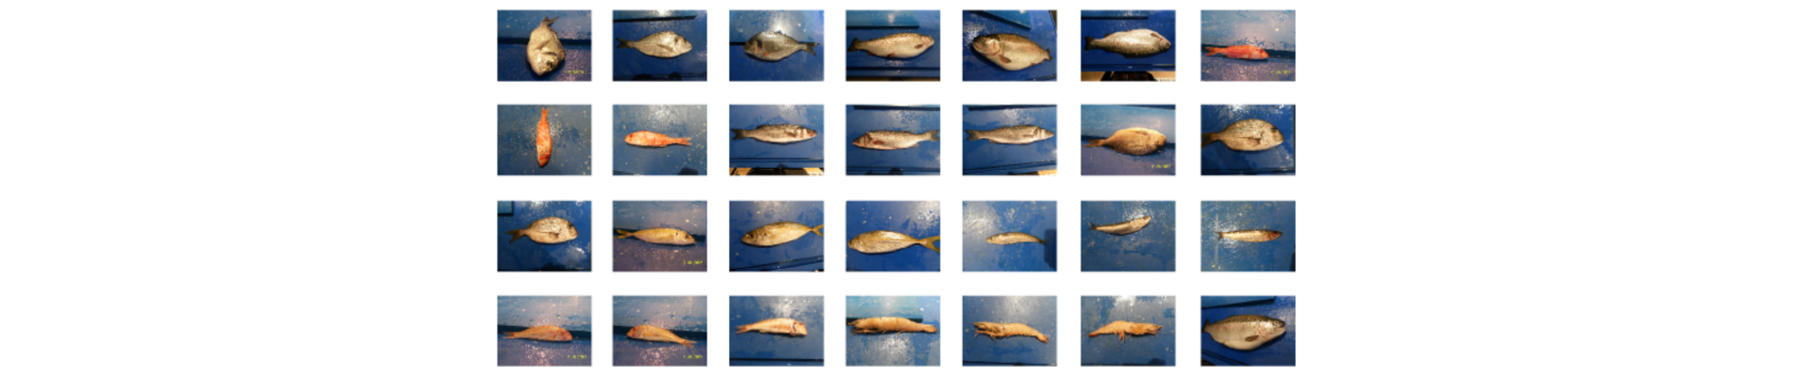

# Kütüphanelerin Yüklenmesi

### Kütüphanelerin Yüklenmesi

| Kütüphane | Amacı |
|-----------|-------|
| `matplotlib` | Görselleştirme |
| `numpy` | Sayısal hesaplamalar |
| `os` | Dosya işlemleri |
| `pandas` | Veri analizi |
| `pathlib` | Yardımcı kütüphane |
| `tensorflow` | Derin öğrenme |
| `warnings` | Uyarı yönetimi |


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import os.path
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img,img_to_array
print("tf versiyon:", tf.__version__)
import warnings
warnings.filterwarnings("ignore")

2024-05-06 08:52:00.193042: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-06 08:52:00.193149: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-06 08:52:00.342480: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


tf versiyon: 2.15.0


# Veri Seti İçeriği

### Dosya yolu ve etiketlerden dataframe oluşturma fonksiyonu

In [2]:
#Dosya yolu ve etiketlerden dataframe oluşturma fonksiyonu
def create_dataset(folders,path):
    data = {'imgpath': [], 'labels': []}
    for folder in folders:
        folderpath = os.path.join(path, folder)
        files = os.listdir(folderpath)
        
        for file in files:
            filepath = os.path.join(folderpath, file)
            data['imgpath'].append(filepath)
            data['labels'].append(folder)

    dataset = pd.DataFrame(data)
    return dataset

In [3]:
ls '/kaggle/input/a-large-scale-fish-dataset/NA_Fish_Dataset'

'Black Sea Sprat'/  'Red Mullet'/      Shrimp/
'Gilt Head Bream'/  'Red Sea Bream'/  'Striped Red Mullet'/
'Horse Mackerel'/   'Sea Bass'/        Trout/


### Veri seti yolu ve klasör adları ile data frame oluştur

In [4]:
# Veri seti yolu ve klasör adları ile data frame oluştur
path1 = '/kaggle/input/a-large-scale-fish-dataset/NA_Fish_Dataset'
folders1 = ['Black Sea Sprat', 'Gilt Head Bream', 'Horse Mackerel', 
            'Red Mullet', 'Red Sea Bream', 'Sea Bass', 'Shrimp', 
            'Striped Red Mullet', 'Trout'] 
df=create_dataset(folders1,path1)
df.head()

,imgpath,labels
0,/kaggle/input/a-large-scale-fish-dataset/NA_Fi...,Black Sea Sprat
1,/kaggle/input/a-large-scale-fish-dataset/NA_Fi...,Black Sea Sprat
2,/kaggle/input/a-large-scale-fish-dataset/NA_Fi...,Black Sea Sprat
3,/kaggle/input/a-large-scale-fish-dataset/NA_Fi...,Black Sea Sprat
4,/kaggle/input/a-large-scale-fish-dataset/NA_Fi...,Black Sea Sprat


### Veri seti bilgileri

In [5]:
# Veri seti bilgileri
print('-- Veri seti bilgileri --\n')
print(f'Görsel Sayısı: {df.shape[0]}\n')
print(f'Etiket sayısı: {len(df.labels.unique())}\n')
print(f'Etiketler {df.labels.unique()}')

-- Veri seti bilgileri --

Görsel Sayısı: 430

Etiket sayısı: 9

Etiketler ['Black Sea Sprat' 'Gilt Head Bream' 'Horse Mackerel' 'Red Mullet'
 'Red Sea Bream' 'Sea Bass' 'Shrimp' 'Striped Red Mullet' 'Trout']


### Görselleştirme

Veriyi grafik ile inceliyoruz.

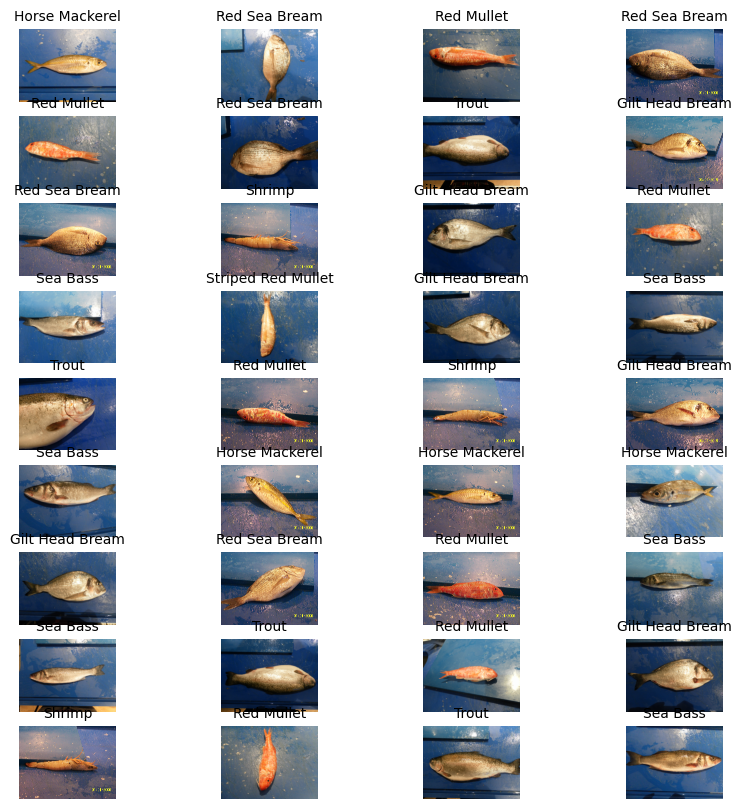

In [6]:
# Veri Görselleştirme
import random
import matplotlib.gridspec as gridspec
from PIL import Image
rows = 9
cols = 4

selected_indices = random.sample(range(len(df)), rows * cols)

fig, axes = plt.subplots(rows, cols, figsize = (10, 10))
gs = gridspec.GridSpec(rows, cols, wspace = 0.0, hspace = 0.0)

for i, idx in enumerate(selected_indices):
    row = i // cols
    col = i % cols
    img_path = df['imgpath'].iloc[idx]
    label = df['labels'].iloc[idx]
    img = Image.open(img_path)
    axes[row, col].imshow(img)
    axes[row, col].axis('off')
    axes[row, col].set_title(label, fontsize = 10)

plt.show()

### Veri Gruplama ve Analiz

Verileri kategorilere göre gruplayıp analiz ediyoruz.

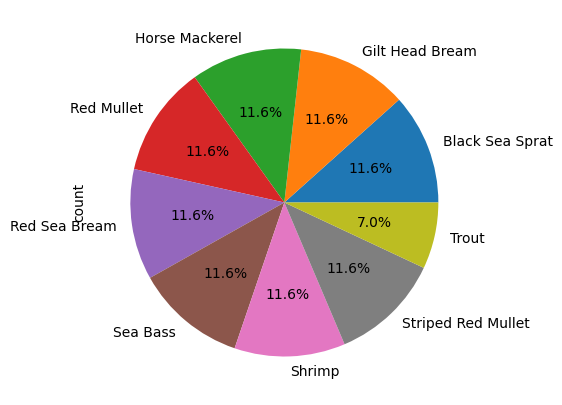

In [7]:
# pie plot label distribution
df.labels.value_counts().plot(kind='pie',autopct='%1.1f%%',figsize=(5,5));

### Split data train, val, test

In [8]:
#Split data train, val, test
train_df, val_df, test_df = np.split(df.sample(frac=1, random_state=42),
                                     [int(.8*len(df)), int(.9*len(df))])
train_df.shape, val_df.shape, test_df.shape

((344, 2), (43, 2), (43, 2))

In [19]:
%%time
# görsel ön işleme ve generator
from tensorflow.keras.preprocessing.image import ImageDataGenerator
seed = 42 #random state=42
batch_size = 32
img_size = (224, 224)

generator = ImageDataGenerator(rescale = 1./255)

train_data = generator.flow_from_dataframe(train_df, x_col = 'imgpath', y_col = 'labels', 
                                           color_mode = 'rgb', class_mode = 'categorical', 
                                           batch_size = batch_size, target_size = img_size, 
                                           shuffle = True, seed = seed)

val_data = generator.flow_from_dataframe(val_df, x_col = 'imgpath', y_col = 'labels', 
                                         color_mode = 'rgb', class_mode = 'categorical', 
                                         batch_size = batch_size, target_size = img_size, 
                                         shuffle = False)

test_data = generator.flow_from_dataframe(test_df, x_col = 'imgpath', y_col = 'labels', 
                                          color_mode = 'rgb', class_mode = 'categorical', 
                                          batch_size = batch_size, target_size = img_size, 
                                          shuffle = False)

Found 344 validated image filenames belonging to 9 classes.
Found 43 validated image filenames belonging to 9 classes.
Found 43 validated image filenames belonging to 9 classes.
CPU times: user 30.2 ms, sys: 13.5 ms, total: 43.7 ms
Wall time: 292 ms


# Model Oluşturma

### Kütüphanelerin Yüklenmesi

| Kütüphane | Amacı |
|-----------|-------|
| `tensorflow` | Derin öğrenme |


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.losses import CategoricalCrossentropy

model = Sequential()
model.add(Input(shape=(224, 224, 3)))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(256, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(9, activation='softmax'))  # 9 kategori

# Modelin derlenmesi
model.compile(optimizer='adam', loss=CategoricalCrossentropy(), metrics=['accuracy'])#kategorik etiketler varsa loss = 'CategoricalCrossentropy()'

In [21]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,108,297 (19.49 MB)

 Trainable params: 5,108,297 (19.49 MB)

 Non-trainable params: 0 (0.00 B)

# Model Eğitme

In [22]:
%%time
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# En düşük loss değerinde eğitimin durmasını sağla
model_es = EarlyStopping(monitor = 'val_loss', mode = 'min', patience = 2, restore_best_weights = True)
model_rlr = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.2, patience = 1, mode = 'min')

history = model.fit(train_data, validation_data = val_data, 
                    epochs = 20, callbacks = [model_es, model_rlr])

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.0797 - loss: 2.2144 - val_accuracy: 0.1395 - val_loss: 2.1575 - learning_rate: 0.0010
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.1942 - loss: 2.0645 - val_accuracy: 0.3953 - val_loss: 1.6533 - learning_rate: 0.0010
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.4907 - loss: 1.4592 - val_accuracy: 0.5349 - val_loss: 1.2877 - learning_rate: 0.0010
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.6175 - loss: 1.0413 - val_accuracy: 0.6047 - val_loss: 1.2303 - learning_rate: 0.0010
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.7172 - loss: 0.7280 - val_accuracy: 0.7442 - val_loss: 1.0494 - learning_rate: 0.0010
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.8243 - loss: 0.4313 - val_accuracy: 0.6977 - val_loss: 1.5645 - learning_rate: 0.0010
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.8693 - loss: 0.3824 - val_accuracy: 

# Modeli Değerlendir

In [23]:
test_results = model.evaluate(test_data, verbose = 0)

print(f'Test Loss: {test_results[0]:.5f}')
print(f'Test Accuracy: {(test_results[1] * 100):.2f}%')

Test Loss: 0.99788
Test Accuracy: 65.12%


### Modeli kaydet

In [ ]:
#Modeli kaydet
model.save('/kaggle/working/fish_class_cnn.h5')

---

<div align="center">

<img src="https://img.shields.io/badge/ECS-Veri%20Bilimi%20%26%20YZ-5B2C1E?style=flat-square&logo=python&logoColor=white" alt="ECS"/>

**Dr. Murat Altun** · Veri Bilimi ve Yapay Zeka Eğitmeni

<a href="https://yapayzekaokulum.com">Yapay Zeka Okulum</a> ·
<a href="https://gencyz.com">GençYZ</a> ·
<a href="https://yz-araclari.com">YZ Araçları</a> ·
<a href="https://scholargent.com">ScholarAI</a> ·
<a href="https://drmurataltun.github.io">Kişisel Site</a>

<a href="https://drmurataltun.github.io/VB-YZ-90/">drmurataltun.github.io/VB-YZ-90</a>

---

*Bu materyal ECS Veri Bilimi ve Yapay Zeka Uzmanlığı Programı için hazırlanmıştır.*

© 2026 Dr. Murat Altun. Tüm hakları saklıdır.

</div>